In [4]:
import sys
import os
from pydataxm.pydatasimem import ReadSIMEM, CatalogSIMEM
import pandas as pd
import requests
import tempfile
from typing import List, Any, Dict, Union

# ---------------------------------------------------------
# 1. FUNCIÓN REUTILIZABLE PARA OBTENER nameColumns
# ---------------------------------------------------------
def obtener_namecolumns(dataset_id: str, url_template: str, timeout: int = 200) -> List[str]:

    if "{dataset_id}" not in url_template:
        raise ValueError("El url_template debe contener {dataset_id}")

    url = url_template.format(dataset_id=dataset_id)
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()

    try:
        data = resp.json()
    except ValueError as e:
        raise ValueError(f"La respuesta no es JSON válido: {e}")

    if data is None:
        raise ValueError("La respuesta JSON está vacía (None).")

    # --- Recorrido recursivo ---
    def _find_namecolumns(obj: Union[Dict, List]) -> List[str]:
        found = []

        def _walk(node):
            if isinstance(node, dict):
                for k, v in node.items():
                    if k.lower() == "columns":  
                        if isinstance(v, list):
                            for item in v:
                                if isinstance(item, dict) and "nameColumn" in item:
                                    found.append(item["nameColumn"])
                        elif isinstance(v, dict):
                            for possible in ("items", "data", "list", "values"):
                                if possible in v and isinstance(v[possible], list):
                                    for item in v[possible]:
                                        if isinstance(item, dict) and "nameColumn" in item:
                                            found.append(item["nameColumn"])
                    _walk(v)
            elif isinstance(node, list):
                for n in node:
                    _walk(n)

        _walk(obj)

        # Únicos manteniendo el orden
        seen = set()
        unique = []
        for col in found:
            if col not in seen:
                seen.add(col)
                unique.append(col)
        return unique

    return _find_namecolumns(data)


# ---------------------------------------------------------
# 2. FUNCIÓN PRINCIPAL UNIFICADA
# ---------------------------------------------------------
def get_df_unificado(
    dataset_id: str,
    fecha_inicio: str,
    fecha_final: str,
    url_template_namecols: str,
    nombre_csv: str | None = None,
) -> Dict[str, Any]:
    """
    Descarga el dataset desde SIMEM, obtiene nameColumns vía API y guarda el CSV
    en un archivo temporal. El archivo temporal se crea con la librería
    estándar `tempfile` y se devuelve su ruta en el diccionario resultante.
    Si se especifica `nombre_csv`, se usará ese nombre dentro del directorio
    de almacenamiento (antigua conducta), pero por defecto se crean archivos
    temporales para no dejar residuos.

    La escritura del CSV se realiza **antes** de consultar el endpoint de
    columnas; cualquier fallo en esa llamada se captura y no evita el retorno
    del diccionario, de modo que siempre se puede inspeccionar `ruta_csv`.
    """

    # --- Obtener dataframe desde SIMEM ---
    catalogo = CatalogSIMEM(catalog_type='Datasets')
    df_catalogo = catalogo.get_data()

    simem = ReadSIMEM(dataset_id, fecha_inicio, fecha_final)
    df_general = simem.main()

    if df_general is None:
        print("Advertencia: ReadSIMEM.main() devolvió None. Se genera DataFrame vacío.")
        df_general = pd.DataFrame()

    # --- Determinar ruta de salida ---
    if nombre_csv:
        # comportamiento legado: escribir en carpeta Almacenamiento
        try:
            base_dir = os.path.dirname(os.path.abspath(__file__))
        except NameError:
            base_dir = os.getcwd()
        carpeta_dos_arriba = os.path.abspath(os.path.join(base_dir, "..", ".."))
        if not os.path.isdir(carpeta_dos_arriba):
            raise FileNotFoundError(
                f"No existe la carpeta dos niveles arriba: {carpeta_dos_arriba}"
            )
        carpeta_almacenamiento = os.path.join(carpeta_dos_arriba, "Almacenamiento")
        os.makedirs(carpeta_almacenamiento, exist_ok=True)
        ruta_csv = os.path.join(carpeta_almacenamiento, nombre_csv)
    else:
        # crear archivo temporal en el sistema (se mantiene tras cerrar)
        # el nombre devuelto se utiliza para almacenamiento externo y puede
        # inspeccionarse/leer desde otra parte del código o el notebook.
        tmp = tempfile.NamedTemporaryFile(prefix="simem_", suffix=".csv", delete=False)
        ruta_csv = tmp.name
        tmp.close()

    # Guardar CSV
    df_general.to_csv(ruta_csv, index=False, encoding="utf-8")
    print(f"CSV guardado en: {ruta_csv}")

    # --- Obtener columnas del endpoint; fallo no debe abortar ---
    try:
        namecolumns = obtener_namecolumns(dataset_id, url_template_namecols)
    except Exception as exc:  # pylint: disable=broad-except
        print(f"Advertencia: error al obtener nameColumns: {exc}")
        namecolumns = []

    # --- Retornar ambos resultados ---
    return {
        "dataframe": df_general,
        "namecolumns": namecolumns,
        "ruta_csv": ruta_csv,
    }

In [5]:
import re
from pathlib import Path
from typing import Dict, Optional, Any
import pandas as pd
import tempfile

ALMACEN_DIR = Path("Almacenamiento")  # Se creará si no existe


# -----------------------------
# Utilidades
# -----------------------------
def _sanitize_filename(text: Any) -> str:
    """Convierte un valor arbitrario en un nombre de archivo seguro."""
    if pd.isna(text):
        return "valor_vacio"
    s = str(text).strip().replace(" ", "_")
    # Elimina caracteres inválidos para nombres de archivo (Windows/Unix)
    s = re.sub(r'[\\/:*?"<>|]+', "", s)
    # Colapsa múltiples '_'
    s = re.sub(r"_+", "_", s)
    # Limita longitud por compatibilidad con distintos FS
    s = s[:120] if len(s) > 120 else s
    return s or "valor_vacio"


def _siguiente_ruta_disponible(base: Path) -> Path:
    """
    Dada una ruta base, si existe, genera base__1, base__2, ... hasta que no exista.
    Ej: 'col_val.csv' -> 'col_val__1.csv', etc.
    """
    if not base.exists():
        return base
    stem, suffix = base.stem, base.suffix
    contador = 1
    while True:
        candidata = base.with_name(f"{stem}__{contador}{suffix}")
        if not candidata.exists():
            return candidata
        contador += 1


def _elegir_columna_interactivo(df: pd.DataFrame) -> str:
    """Muestra columnas y permite elegir por número o por nombre (exacto)."""
    columnas = list(df.columns)
    print("\nColumnas disponibles:")
    for i, c in enumerate(columnas, start=1):
        print(f"  {i}. {c}")

    entrada = input("\nElige la columna (número o nombre exacto): ").strip()
    if not entrada:
        raise ValueError("No ingresaste una selección de columna.")

    # Intento por número
    if entrada.isdigit():
        idx = int(entrada)
        if not (1 <= idx <= len(columnas)):
            raise IndexError(f"Índice fuera de rango (1..{len(columnas)}).")
        return columnas[idx - 1]

    # Intento por nombre exacto (respeta mayúsculas/acentos)
    if entrada in df.columns:
        return entrada

    # Intento tolerante: ignorando espacios extremos
    candidato = entrada.strip()
    if candidato in df.columns:
        return candidato

    raise KeyError(f"La columna '{entrada}' no existe. Revisa la lista mostrada.")


def _elegir_valor_interactivo(serie: pd.Series) -> Any:
    """
    Lista valores únicos (preservando orden de aparición), muestra conteos y permite elegir uno.
    Retorna el valor real seleccionado (incluye NaN si se elige).
    """
    serie_obj = serie.astype("object")

    # Preserva orden de aparición
    valores_unicos = serie_obj.drop_duplicates(keep="first")

    # Asegura incluir NaN explícitamente si existe (y no está ya)
    if serie_obj.isna().any() and not valores_unicos.isna().any():
        valores_unicos = pd.concat([valores_unicos, pd.Series([float("nan")])], ignore_index=True)

    # Arma lista [(label, valor_real, conteo)]
    items = []
    for v in valores_unicos:
        if pd.isna(v):
            cnt = serie_obj.isna().sum()
            label = "NaN"
        else:
            cnt = (serie_obj == v).sum()
            label = str(v)
        items.append((label, v, cnt))

    # Métricas informativas
    unicos_con_nombre = [it for it in items if not pd.isna(it[1])]
    filas_nan = serie_obj.isna().sum()

    print("\nResumen de la columna seleccionada:")
    print(f"  - Valores con nombre (no vacíos): {len(unicos_con_nombre)}")
    print(f"  - Filas NaN (vacías): {filas_nan}")

    print("\nValores disponibles (en orden de aparición):")
    for i, (label, _valor, cnt) in enumerate(items, start=1):
        print(f"  {i}. {label}  →  {cnt} filas")

    entrada = input("\nElige el valor (número o etiqueta exacta mostrada): ").strip()
    if not entrada:
        raise ValueError("No ingresaste una selección de valor.")

    # Por número
    if entrada.isdigit():
        idx = int(entrada)
        if not (1 <= idx <= len(items)):
            raise IndexError(f"Índice fuera de rango (1..{len(items)}).")
        return items[idx - 1][1]

    # Por etiqueta exacta (la que imprimimos)
    for label, valor, _cnt in items:
        if entrada == label:
            return valor

    raise KeyError(f"El valor '{entrada}' no se encuentra en la lista mostrada.")


# -----------------------------
# Núcleo de exportación
# -----------------------------
def exportar_por_columna(
    df: pd.DataFrame,
    columna: str,
    carpeta_salida: Path | str | None = None,
    prefijo_archivo: Optional[str] = None,
    guardar_indice: bool = False,
    crear_carpeta_si_no_existe: bool = True,
    valor_objetivo: Optional[Any] = None,
):
    """
    Exporta CSV según 'valor_objetivo'.

    Por defecto (cuando `carpeta_salida` es None) cada resultado se guarda en
    un **archivo temporal** y el diccionario devuelto usa las rutas de dichos
    archivos. Si se proporciona `carpeta_salida` se seguirá el comportamiento
    clásico de escribir en disco dentro de esa carpeta (creándola si es
    necesario).

    Retorna:
        resultados -> dict con {ruta_archivo: filas}
        subset     -> df filtrado según el valor elegido
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("El parámetro 'df' debe ser un pandas.DataFrame.")
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe. Columnas disponibles: {list(df.columns)}")

    usar_temp = carpeta_salida is None
    carpeta: Path | None = None
    if not usar_temp:
        # inicializar carpeta únicamente si no se usarán archivos temporales
        carpeta = Path(carpeta_salida)  # type: ignore[arg-type]
        if not carpeta.exists():
            if crear_carpeta_si_no_existe:
                carpeta.mkdir(parents=True, exist_ok=True)
            else:
                raise FileNotFoundError(f"La carpeta destino '{carpeta}' no existe.")

    # cuando usar_temp es True no se emplea la variable `carpeta` en absoluto

    serie = df[columna].astype("object")

    resultados = {}
    safe_prefix = _sanitize_filename((prefijo_archivo or columna).strip())

    # --- Exportar SOLO el valor elegido ---
    if valor_objetivo is not None:

        if pd.isna(valor_objetivo):
            mascara = serie.isna()
            etiqueta = "NaN"
        else:
            mascara = serie == valor_objetivo
            etiqueta = str(valor_objetivo)

        subset = df.loc[mascara]

        if subset.empty:
            return {}, subset

        safe_val = _sanitize_filename(etiqueta)
        if usar_temp:
            tmp = tempfile.NamedTemporaryFile(prefix=f"{safe_prefix}_{safe_val}_", suffix=".csv", delete=False)
            ruta_final = tmp.name
            tmp.close()
        else:
            assert carpeta is not None  # carpeta sólo puede ser None si usar_temp es True
            ruta = carpeta / f"{safe_prefix}_{safe_val}.csv"
            ruta_final = _siguiente_ruta_disponible(ruta)

        subset.to_csv(ruta_final, index=guardar_indice)
        resultados[str(ruta_final)] = len(subset)

        return resultados, subset  # ← DEVUELVE EL DATAFRAME FILTRADO

    # --- Exportar TODOS (modo clásico) ---
    valores_unicos = serie.drop_duplicates(keep="first")

    if serie.isna().any() and not valores_unicos.isna().any():
        valores_unicos = pd.concat([valores_unicos, pd.Series([float('nan')])], ignore_index=True)

    # Exportación en lote
    for val in valores_unicos:
        if pd.isna(val):
            mascara = serie.isna()
            etiqueta = "NaN"
        else:
            mascara = serie == val
            etiqueta = str(val)

        subset = df.loc[mascara]

        if subset.empty:
            continue

        safe_val = _sanitize_filename(etiqueta)
        if usar_temp:
            tmp = tempfile.NamedTemporaryFile(prefix=f"{safe_prefix}_{safe_val}_", suffix=".csv", delete=False)
            ruta_final = tmp.name
            tmp.close()
        else:
            assert carpeta is not None
            ruta = carpeta / f"{safe_prefix}_{safe_val}.csv"
            ruta_final = _siguiente_ruta_disponible(ruta)

        subset.to_csv(ruta_final, index=guardar_indice)
        resultados[str(ruta_final)] = len(subset)

    return resultados, df  # ← si exporta todo, devuelve df original

def ejecutar_interactivo(df: pd.DataFrame):
    print("=== Exportar CSV por un valor específico de una columna ===")
    print("Generando archivos temporales (no se usa carpeta fija)")

    columna = _elegir_columna_interactivo(df)
    print(f"\nTrabajando con la columna: {columna}")

    valor = _elegir_valor_interactivo(df[columna])

    resultados, df_seleccion = exportar_por_columna(
        df=df,
        columna=columna,
        carpeta_salida=None,
        prefijo_archivo=columna,
        guardar_indice=False,
        crear_carpeta_si_no_existe=True,
        valor_objetivo=valor
    )

    if not resultados:
        print("\n[INFO] No se generó archivo (subset vacío).")
        return df_seleccion

    total = sum(resultados.values())
    print(f"\n[OK] Se generó {len(resultados)} archivo(s).")
    print(f"[OK] Filas exportadas: {total}")

    for ruta, n in sorted(resultados.items()):
        print(f"  - {Path(ruta).name} → {n} filas")

    return df_seleccion  # ← AQUÍ DEVUELVE EL DF FILTRADO

In [6]:
import pandas as pd

def Separacion(columnas, archivo):
    """
    Separa un DataFrame en dos: uno con var_x y var_y (df_general), y otro con el resto (df_atributos).
    Permite renombrar interactivamente SOLO las dos columnas de df_general.

    Args:
        columnas: Lista de nombres de columnas disponibles (no usada, se valida desde el DataFrame).
        archivo: DataFrame de entrada.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (df_general con 2 columnas, df_atributos con el resto)
    """
    # Validaciones iniciales
    if not isinstance(archivo, pd.DataFrame):
        raise TypeError(f"Se esperaba DataFrame, recibido: {type(archivo)}")
    if archivo.empty:
        raise ValueError("El DataFrame está vacío")

    # Columnas válidas desde el DataFrame real
    columnas_validas = list(archivo.columns)

    # --- Selección de variable X ---
    while True:
        var_x = input("Variable eje X: ").strip()
        if var_x in columnas_validas:
            break
        print(f"Columna no encontrada. Disponibles: {columnas_validas}")

    # --- Selección de variable Y ---
    while True:
        var_y = input("Variable eje Y: ").strip()
        if var_y == var_x:
            print("La variable Y no puede ser igual a X")
            continue
        if var_y in columnas_validas:
            break
        print(f"Columna no encontrada. Disponibles: {columnas_validas}")

    # --- Construcción de df_general y df_atributos ---
    df_general = archivo[[var_x, var_y]].copy()

    # Convertir X a datetime (intento estricto + flexible)
    try:
        df_general[var_x] = pd.to_datetime(df_general[var_x], format='%Y-%m-%d %H:%M:%S')
    except Exception:
        df_general[var_x] = pd.to_datetime(df_general[var_x], errors='coerce', dayfirst=False)

    df_atributos = archivo.drop([var_x, var_y], axis=1).copy()

    # --- Renombrado interactivo de SOLO X e Y ---
    print("\n=== Renombrar columnas de df_general (solo X e Y) ===")
    print(f"Nombre actual de X: {var_x}")
    nuevo_x = input("Nuevo nombre para X (Enter para conservar): ").strip()
    if not nuevo_x:
        nuevo_x = var_x

    print(f"Nombre actual de Y: {var_y}")
    nuevo_y = input("Nuevo nombre para Y (Enter para conservar): ").strip()
    if not nuevo_y:
        nuevo_y = var_y

    # Validaciones de los nuevos nombres
    if not nuevo_x:
        raise ValueError("El nombre para X no puede ser vacío.")
    if not nuevo_y:
        raise ValueError("El nombre para Y no puede ser vacío.")
    if nuevo_x == nuevo_y:
        raise ValueError("Los nombres de X e Y no pueden ser iguales.")

    # Aplicar renombre en df_general
    df_general.rename(columns={var_x: nuevo_x, var_y: nuevo_y}, inplace=True)

    # Validaciones finales
    assert isinstance(df_general, pd.DataFrame), "df_general no es DataFrame"
    assert isinstance(df_atributos, pd.DataFrame), "df_atributos no es DataFrame"
    assert df_general.shape[1] == 2, f"df_general debe tener 2 columnas, tiene {df_general.shape[1]}"

    return df_general, df_atributos

In [7]:
import pandas as pd
import tempfile

def obtener_columnas_df(df: pd.DataFrame) -> list:
    """
    Retorna la lista de nombres de columnas de un DataFrame.

    Args:
        df (pd.DataFrame): DataFrame del que se quieren las columnas.

    Returns:
        list: nombres de las columnas.
    """
    if df is None:
        raise ValueError("El DataFrame no puede ser None")
    columnas = df.columns.tolist()
    print(f"Columnas del DataFrame: {columnas}")
    return columnas

# si aún se necesita leer desde un archivo plano
def obtener_columnas_archivo(ruta_archivo, crear_temp: bool = True):
    """
    Lee un archivo plano y retorna sus columnas.

    Si `crear_temp` es True se genera un archivo temporal con sólo las
    cabeceras (mismas columnas) y se devuelve la ruta junto con la lista de
    columnas; esto asegura que cualquier fichero que produzca este código sea
    temporal y no deje residuos.

    Args:
        ruta_archivo (str): camino al archivo CSV.
        crear_temp (bool): controla la creación del fichero temporal.

    Returns:
        tuple[list, Optional[str]]: (columnas, ruta_temp)
    """
    try:
        df = pd.read_csv(ruta_archivo, sep=',', nrows=1)  # ajustar sep si hace falta
        columnas = df.columns.tolist()
        print(f"Columnas encontradas: {columnas}")

        ruta_temp = None
        if crear_temp:
            tmp = tempfile.NamedTemporaryFile(prefix="cols_", suffix=".csv", delete=False)
            df.head(0).to_csv(tmp.name, index=False)
            ruta_temp = tmp.name
            tmp.close()
            print(f"Archivo temporal creado: {ruta_temp}")

        return columnas, ruta_temp
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en {ruta_archivo}")
        return [], None
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return [], None




In [43]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Union

def preparar_largo_desde_lista(
    dfs: List[pd.DataFrame],
    x_col: str = "fecha",
    y_cols: Optional[List[str]] = None,   # si None: intenta ['valor'] o detecta numéricas
    label_col: Optional[str] = None,      # si None: se creará un label por DF (DF1, DF2,...)
    max_series: int = 5
) -> pd.DataFrame:
    """
    Convierte una lista de DataFrames a un DF "largo" con columnas: [fecha, valor, serie].
    - Si y_cols tiene varias columnas, cada una se vuelve una serie separada por DF.
    - Si label_col existe, se usa como nombre de serie; si no, se crea TIPO DF{i}/col.
    - Limita a `max_series` series (para evitar saturación visual).
    """
    largos = []
    serie_count = 0

    for i, df in enumerate(dfs, start=1):
        if df is None or df.empty:
            continue
        tmp = df.copy()

        # Asegurar x_col como datetime si existe
        if x_col in tmp.columns:
            tmp[x_col] = pd.to_datetime(tmp[x_col], errors="coerce")
            tmp = tmp.dropna(subset=[x_col]).sort_values(x_col)
        else:
            # Si no hay x_col, usamos un índice numérico convertido a fechas relativas
            # (no ideal para calendario, pero permite graficar).
            tmp = tmp.reset_index(drop=True)
            tmp[x_col] = pd.to_datetime(np.arange(len(tmp)), unit="D", origin="2025-01-01")

        # Determinar columnas de valor
        if y_cols is None:
            if "valor" in tmp.columns:
                cols_val = ["valor"]
            else:
                cols_val = [c for c in tmp.columns if c != x_col and pd.api.types.is_numeric_dtype(tmp[c])]
        else:
            cols_val = [c for c in y_cols if c in tmp.columns and c != x_col]

        if not cols_val:
            continue

        # Armar "largo": (fecha, valor, serie)
        if label_col and (label_col in tmp.columns):
            # Una serie por unique(label) por cada columna en cols_val
            for col in cols_val:
                sub = tmp[[x_col, col, label_col]].dropna()
                if sub.empty: 
                    continue
                sub = sub.rename(columns={x_col: "fecha", col: "valor", label_col: "serie"})
                # 1 serie por valor único en 'serie'
                for s in sub["serie"].unique():
                    parte = sub[sub["serie"] == s][["fecha", "valor"]].copy()
                    parte["serie"] = str(s)
                    largos.append(parte)
                    serie_count += 1
                    if serie_count >= max_series:
                        break
                if serie_count >= max_series:
                    break
        else:
            # Sin label: crea una serie por cada col de valor y por cada DF
            for col in cols_val:
                sub = tmp[[x_col, col]].dropna()
                if sub.empty:
                    continue
                parte = sub.rename(columns={x_col: "fecha", col: "valor"})
                parte["serie"] = f"DF{i}/{col}"
                largos.append(parte[["fecha", "valor", "serie"]])
                serie_count += 1
                if serie_count >= max_series:
                    break

        if serie_count >= max_series:
            break

    if not largos:
        raise ValueError("No se encontraron series válidas para graficar.")

    largo = pd.concat(largos, ignore_index=True)
    # Agregar seguridad por si hay duplicados por fecha/serie
    largo = (
        largo.groupby(["fecha", "serie"], as_index=False)["valor"]
        .mean()
        .sort_values("fecha")
    )
    return largo


def plot_series_desde_lista(
    dfs: List[pd.DataFrame],
    x_col: str = "fecha",
    y_cols: Optional[List[str]] = None,
    label_col: Optional[str] = None,
    titulo: str = "Comparación de series",
    unidad: str = "",
    normalizar: bool = False,
    apilado: bool = False,  # True=área apilada, False=líneas superpuestas
    max_series: int = 5,
    figsize=(12, 6)
):
    """
    Lee una lista de DataFrames y grafica hasta 5 series en una sola figura (plt/sns).
    - apilado=True: área apilada (stackplot).
    - apilado=False: líneas superpuestas.
    - normalizar=True: normaliza cada serie a [0,1].
    Muestra inmediatamente (no guarda).
    """
    sns.set(style="whitegrid")
    largo = preparar_largo_desde_lista(
        dfs, x_col=x_col, y_cols=y_cols, label_col=label_col, max_series=max_series
    )

    # Normalizar si aplica (por serie)
    if normalizar:
        largo["valor"] = largo.groupby("serie")["valor"].transform(
            lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else 0.0
        )

    fig, ax = plt.subplots(figsize=figsize)

    if apilado:
        # Pivot para stackplot (área apilada)
        piv = largo.pivot(index="fecha", columns="serie", values="valor").sort_index().fillna(0.0)
        x = piv.index
        ys = piv.values.T  # shape: (n_series, n_points)
        labels = piv.columns.tolist()
        ax.stackplot(x, ys, labels=labels, alpha=0.85)
    else:
        # Líneas superpuestas
        for serie, sub in largo.groupby("serie"):
            sub = sub.sort_values("fecha")
            ax.plot(sub["fecha"], sub["valor"], label=str(serie), linewidth=2)

    # Títulos y ejes
    ax.set_title(titulo + (" (normalizado)" if normalizar else ""), fontsize=15)
    ax.set_xlabel("Tiempo")
    ax.set_ylabel(f"Valor {unidad}".strip())
    ax.legend(ncol=2, frameon=True, fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [9]:
from datetime import date
from dateutil.relativedelta import relativedelta   # viene con python‑dateutil

hoy = date.today()
tres_meses_atras = hoy - relativedelta(months=3)

Seleccion = input('¿Trabajara con DataSets o con Archivos Planos? (D/A): ').lower()

if Seleccion == "d":
    ## Solicitud de set##
    input_set = input("Ingrese el dataset ID a tratar: ")
    print("Porfavor, ingrese el rango de fechas a tratar, si no se ingresa nada, se tomara el ultimos tres meses de datos disponibles")
    FechaInicio = input("Ingrese la fecha de inicio (YYYY-MM-DD): ")

    if not FechaInicio:
        FechaInicio = tres_meses_atras.isoformat()

    print ("Fecha de inicio:", FechaInicio)
    FechaFin = input("Ingrese la fecha de fin (YYYY-MM-DD): ")
    if not FechaFin:
        FechaFin = hoy.isoformat()

    print ("Fecha de fin:", FechaFin)

    resultado = get_df_unificado(
        dataset_id=input_set,
        fecha_inicio=FechaInicio,
        fecha_final=FechaFin,
        url_template_namecols="https://www.simem.co/backend-files/api/detalle-datos-publicos?datasetId={dataset_id}",
        nombre_csv=f"data_{input_set}.csv"
    )

    df = resultado["dataframe"]
    columnas = resultado["namecolumns"]

if Seleccion == "a":
    print("Tomate")
    ruta_archivo = input("Ingrese la ruta del archivo plano: ")
    df = load_to_dataframe(ruta_archivo)
    columnas = obtener_columnas_df(df)



Porfavor, ingrese el rango de fechas a tratar, si no se ingresa nada, se tomara el ultimos tres meses de datos disponibles
Fecha de inicio: 2025-12-03
Fecha de fin: 2026-03-03
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Generación Energético Mediano Plazo"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0052225589752197266
Extraccion de registros: 26.8241446018219
End of data extracting process
****************************************************************************************************
CSV guardado en: d:\ambiente\escritorio\Almacenamiento\data_6781a0.csv


In [52]:
data = []
### FIltro de columnas


def si_no(prompt: str) -> bool:
    while True:
        r = input(f"{prompt} (s/n): ").strip().lower()
        if r in ("s", "n"):
            return r == "s"
        print("→ Por favor responde con 's' o 'n'.")

y = True
while y:
    print("\n=== Nueva ronda de filtrado ===")
    df_filtro = ejecutar_interactivo(df)

    while si_no("¿Añadir otro filtro sobre el resultado actual?"):
        df_filtro = ejecutar_interactivo(df_filtro)

    data.append(df_filtro.copy())
    print("Resultado guardado.")

    y = si_no("¿Empezar a filtrar otro atributo (reiniciar desde df)?")




=== Nueva ronda de filtrado ===
=== Exportar CSV por un valor específico de una columna ===
Generando archivos temporales (no se usa carpeta fija)

Columnas disponibles:
  1. FechaPublicacion
  2. Etapa
  3. FechaInicio
  4. FechaFin
  5. Caso
  6. NombreCaso
  7. TipoGeneracion
  8. TipoEnergetico
  9. CodigoAreaOperativa
  10. GeneracionProyectada
  11. AnioEstudio
  12. SemanaEstudio

Trabajando con la columna: Etapa

Resumen de la columna seleccionada:
  - Valores con nombre (no vacíos): 104
  - Filas NaN (vacías): 0

Valores disponibles (en orden de aparición):
  1. 91  →  5520 filas
  2. 90  →  5520 filas
  3. 82  →  5760 filas
  4. 77  →  5640 filas
  5. 83  →  5640 filas
  6. 96  →  5520 filas
  7. 93  →  5520 filas
  8. 99  →  5200 filas
  9. 98  →  5200 filas
  10. 71  →  5640 filas
  11. 75  →  5640 filas
  12. 85  →  5520 filas
  13. 74  →  5640 filas
  14. 73  →  5640 filas
  15. 86  →  5520 filas
  16. 88  →  5520 filas
  17. 89  →  5520 filas
  18. 63  →  5560 filas
  1

In [53]:
data1 = data[0]
data2 = data[1]
data1.head()




,FechaPublicacion,Etapa,FechaInicio,FechaFin,Caso,NombreCaso,TipoGeneracion,TipoEnergetico,CodigoAreaOperativa,GeneracionProyectada,AnioEstudio,SemanaEstudio
61910,2026-03-01,4,2026-03-23,2026-03-29,Estocastico,Promedio,Solar,Sol,Are0012,1837068.375,2026,9
75250,2026-02-24,4,2026-03-16,2026-03-22,Estocastico,Promedio,Solar,Sol,Are0012,1866835.500,2026,8
101996,2026-02-15,4,2026-03-09,2026-03-15,Estocastico,Promedio,Solar,Sol,Are0012,1813208.125,2026,7
131965,2026-02-08,4,2026-03-02,2026-03-08,Estocastico,Promedio,Solar,Sol,Are0012,2195786.000,2026,6
186068,2026-02-01,4,2026-02-23,2026-03-01,Estocastico,Promedio,Solar,Sol,Are0012,1956400.750,2026,5


In [54]:
data2.head()

,FechaPublicacion,Etapa,FechaInicio,FechaFin,Caso,NombreCaso,TipoGeneracion,TipoEnergetico,CodigoAreaOperativa,GeneracionProyectada,AnioEstudio,SemanaEstudio
61921,2026-03-01,4,2026-03-23,2026-03-29,Estocastico,Promedio,Hidraulica,Agua,Are0012,34782824.0,2026,9
75261,2026-02-24,4,2026-03-16,2026-03-22,Estocastico,Promedio,Hidraulica,Agua,Are0012,38401516.0,2026,8
102007,2026-02-15,4,2026-03-09,2026-03-15,Estocastico,Promedio,Hidraulica,Agua,Are0012,31652426.0,2026,7
131954,2026-02-08,4,2026-03-02,2026-03-08,Estocastico,Promedio,Hidraulica,Agua,Are0012,36029976.0,2026,6
186057,2026-02-01,4,2026-02-23,2026-03-01,Estocastico,Promedio,Hidraulica,Agua,Are0012,33387354.0,2026,5


In [59]:
sep = []
for i in range(len(data)):
    df_filtro = data[i]
    df_general , meta = Separacion(columnas, df_filtro)
    sep.append(df_general)

factor_de_escalado = input("Ingrese el factor de escalado para la segunda columna: ")

for i in range(len(sep)):
    df_general = sep[i]
    # Cambia la parte donde se asignan las columnas en df_general
    df_general.iloc[:, 0] = pd.to_datetime(df_general.iloc[:, 0])  # Convertir la primera columna a fecha
    df_general = df_general.sort_values(by=df_general.columns[0])  # Ordenar por la primera columna
    df_general.iloc[:, 1] = df_general.iloc[:, 1].div(float(factor_de_escalado))  # Dividir la segunda columna por el factor de escalado
    print(factor_de_escalado)



=== Renombrar columnas de df_general (solo X e Y) ===
Nombre actual de X: FechaInicio
Nombre actual de Y: GeneracionProyectada
Columna no encontrada. Disponibles: ['FechaPublicacion', 'Etapa', 'FechaInicio', 'FechaFin', 'Caso', 'NombreCaso', 'TipoGeneracion', 'TipoEnergetico', 'CodigoAreaOperativa', 'GeneracionProyectada', 'AnioEstudio', 'SemanaEstudio']

=== Renombrar columnas de df_general (solo X e Y) ===
Nombre actual de X: FechaInicio
Nombre actual de Y: GeneracionProyectada
1000000
1000000


In [60]:
info1 = sep[0]
info2 = sep[1]

In [61]:
info1.head()


,Fecha,Solar
61910,2026-03-23,1837068.375
75250,2026-03-16,1866835.500
101996,2026-03-09,1813208.125
131965,2026-03-02,2195786.000
186068,2026-02-23,1956400.750


In [62]:
info2.head()

,Fecha,Solar
61921,2026-03-23,34782824.0
75261,2026-03-16,38401516.0
102007,2026-03-09,31652426.0
131954,2026-03-02,36029976.0
186057,2026-02-23,33387354.0


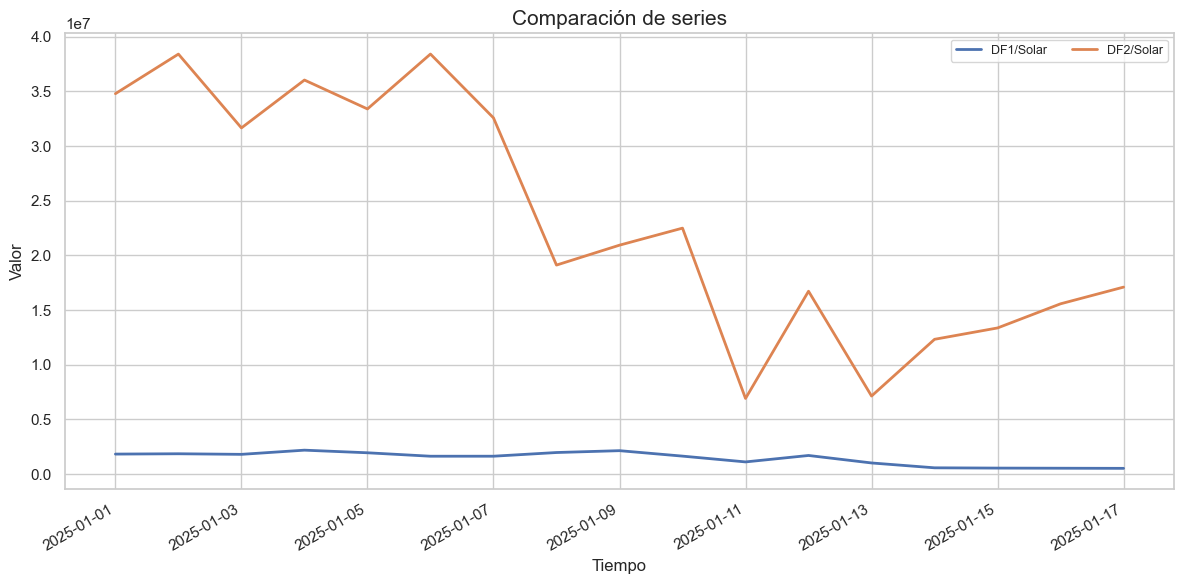

None


In [64]:
grafica = plot_series_desde_lista(sep)

print(grafica)